In [34]:
import pandas as pd
import numpy as np
from numpy.ma.core import remainder
from sklearn.metrics._plot import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector,make_column_transformer
from sklearn.ensemble import RandomForestClassifier

In [35]:
df=pd.read_csv("../Datasets/Sonar.csv")

In [36]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41',
       'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51',
       'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'Class'],
      dtype='str')

In [37]:
le=LabelEncoder()
X=df.drop(columns=["Class"])
Y=le.fit_transform(df["Class"])
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [38]:
print(Y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [39]:
rf=RandomForestClassifier(random_state=25)
rf.fit(X_train,Y_train)
y_pred=rf.predict(X_test)
print(f"classification report:\n",classification_report(Y_test,y_pred))


classification report:
               precision    recall  f1-score   support

           0       0.66      0.97      0.79        34
           1       0.92      0.41      0.57        29

    accuracy                           0.71        63
   macro avg       0.79      0.69      0.68        63
weighted avg       0.78      0.71      0.69        63



In [40]:
features=[2,3,4,5,6,7,8,9,10]
score=list()
for f in features:
    rf=RandomForestClassifier(random_state=25,max_features=f)
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    score.append([f,accuracy_score(Y_test,y_pred)])
score_df=pd.DataFrame(score,columns=[ "no_of_feature","Accuracy"]).sort_values("Accuracy",ascending=False)
print(score_df)

   no_of_feature  Accuracy
3              5  0.761905
2              4  0.746032
1              3  0.746032
8             10  0.730159
4              6  0.730159
0              2  0.714286
5              7  0.714286
6              8  0.714286
7              9  0.698413


In [41]:
ddc=DecisionTreeClassifier(random_state=25)
ddc.fit(X,Y)
imp=pd.DataFrame({
    "Features":list(X.columns),
    "imp":ddc.feature_importances_,
})

In [42]:
print(imp.sort_values("imp",ascending=False))

   Features       imp
10      V11  0.312105
3        V4  0.098697
15      V16  0.090808
30      V31  0.072352
44      V45  0.053523
27      V28  0.049621
33      V34  0.046403
8        V9  0.042149
35      V36  0.038959
51      V52  0.037061
0        V1  0.033895
19      V20  0.023735
43      V44  0.018996
2        V3  0.018373
1        V2  0.016904
13      V14  0.014489
57      V58  0.012879
36      V37  0.009659
17      V18  0.009395
12      V13  0.000000
11      V12  0.000000
9       V10  0.000000
6        V7  0.000000
7        V8  0.000000
5        V6  0.000000
14      V15  0.000000
16      V17  0.000000
4        V5  0.000000
26      V27  0.000000
25      V26  0.000000
24      V25  0.000000
23      V24  0.000000
21      V22  0.000000
22      V23  0.000000
20      V21  0.000000
18      V19  0.000000
34      V35  0.000000
32      V33  0.000000
38      V39  0.000000
37      V38  0.000000
39      V40  0.000000
29      V30  0.000000
31      V32  0.000000
28      V29  0.000000
42      V4

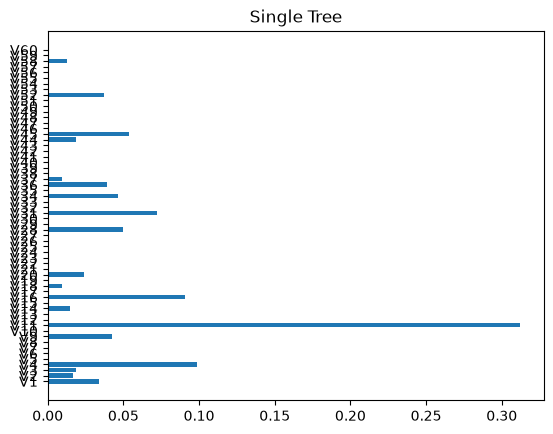

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.Figure(figsize=(10,5))
plt.barh(imp["Features"],imp["imp"])
plt.title("Single Tree")
plt.show()

In [44]:
rf=RandomForestClassifier(random_state=25,max_features=5)
rf.fit(X,Y)
imp=pd.DataFrame({
    "Features":list(X.columns),
    "imp":rf.feature_importances_,
})
print(imp.sort_values("imp",ascending=False))


   Features       imp
11      V12  0.067576
9       V10  0.042815
10      V11  0.040688
8        V9  0.038414
12      V13  0.036021
48      V49  0.029606
47      V48  0.027287
44      V45  0.026189
46      V47  0.026128
35      V36  0.023587
51      V52  0.023064
3        V4  0.021908
45      V46  0.019887
27      V28  0.019653
22      V23  0.019466
26      V27  0.018410
50      V51  0.018410
20      V21  0.017407
19      V20  0.017148
43      V44  0.016774
7        V8  0.016237
0        V1  0.015737
13      V14  0.015535
30      V31  0.015307
34      V35  0.015184
42      V43  0.014684
4        V5  0.013631
23      V24  0.013475
15      V16  0.013468
25      V26  0.013327
17      V18  0.013002
36      V37  0.012894
16      V17  0.012782
5        V6  0.012758
38      V39  0.012656
14      V15  0.012207
18      V19  0.012179
1        V2  0.012156
28      V29  0.011403
21      V22  0.011215
6        V7  0.011173
49      V50  0.010551
54      V55  0.010487
31      V32  0.010233
39      V4

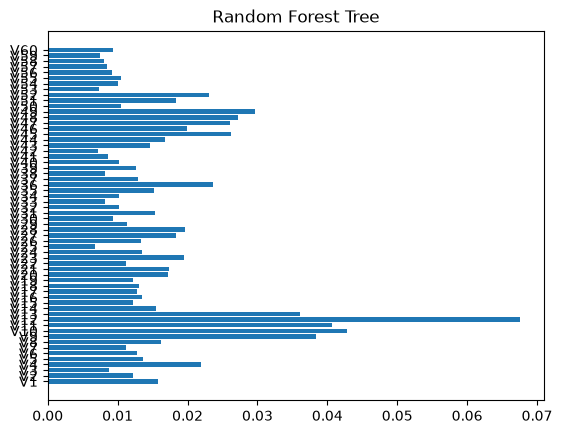

In [45]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(10,5))
plt.barh(imp["Features"],imp["imp"])
plt.title("Random Forest Tree")
plt.show()